In [5]:
import os
import re
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

# STEP 1: LOAD THE DATASET

csv_path = "IMDB Dataset.csv"

df = pd.read_csv(csv_path, engine='python')

print("Dataset shape:", df.shape)
print(df.head())
print("\nClass balance:\n", df["sentiment"].value_counts())

Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Class balance:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
# STEP 2: TEXT PREPROCESSING

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)          #removes unnecessary words and symbols

print("\nCleaning text... (this may take a minute for 50K reviews)")
df["clean_review"] = df["review"].apply(clean_text)

df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("\nBefore cleaning:\n", df["review"].iloc[0][:300])
print("\nAfter cleaning:\n", df["clean_review"].iloc[0][:300])


Cleaning text... (this may take a minute for 50K reviews)

Before cleaning:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

After cleaning:
 one reviewers mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum


In [7]:
# STEP 3: TRAIN/TEST SPLIT

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")




Train size: 40000, Test size: 10000


In [8]:
# STEP 4: TF-IDF FEATURE EXTRACTION

print("\n===== Extracting TF-IDF features =====")
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)




===== Extracting TF-IDF features =====


In [9]:
# STEP 5: TRAIN THE MODEL (LOGISTIC REGRESSION)

print("\n===== Training Logistic Regression model =====")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)



===== Training Logistic Regression model =====


LogisticRegression(max_iter=1000)

In [10]:
# STEP 6: EVALUATE THE MODEL

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== Model Evaluation =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.close()
print("\nConfusion matrix saved as 'confusion_matrix.png'")



===== Model Evaluation =====
Accuracy : 0.8940
Precision: 0.8872
Recall   : 0.9028
F1-score : 0.8949

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Confusion matrix saved as 'confusion_matrix.png'


In [11]:
# STEP 7: LOOK AT THE MOST INFLUENTIAL WORDS

feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_positive_idx = coefficients.argsort()[-15:][::-1]
top_negative_idx = coefficients.argsort()[:15]

print("\nTop words pushing toward POSITIVE sentiment:")
for i in top_positive_idx:
    print(f"  {feature_names[i]:15s}  weight = {coefficients[i]:.3f}")

print("\nTop words pushing toward NEGATIVE sentiment:")
for i in top_negative_idx:
    print(f"  {feature_names[i]:15s}  weight = {coefficients[i]:.3f}")



Top words pushing toward POSITIVE sentiment:
  great            weight = 7.379
  excellent        weight = 7.102
  perfect          weight = 5.664
  amazing          weight = 5.283
  best             weight = 4.921
  loved            weight = 4.817
  wonderful        weight = 4.754
  hilarious        weight = 4.731
  enjoyed          weight = 4.553
  favorite         weight = 4.515
  brilliant        weight = 4.193
  highly           weight = 4.058
  fun              weight = 4.030
  superb           weight = 3.991
  enjoyable        weight = 3.988

Top words pushing toward NEGATIVE sentiment:
  worst            weight = -10.789
  waste            weight = -8.274
  awful            weight = -8.050
  bad              weight = -7.702
  boring           weight = -6.605
  terrible         weight = -6.005
  poor             weight = -5.935
  nothing          weight = -5.480
  dull             weight = -5.371
  horrible         weight = -5.292
  poorly           weight = -5.240
  worse     

In [12]:
# STEP 8: TRY IT  - predict sentiment on a custom review

def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][pred]
    label = "Positive" if pred == 1 else "Negative"
    return label, prob

sample_reviews = [
    "This movie was an absolute masterpiece, brilliant acting and story.",
    "Waste of time. Boring plot and terrible acting.",
]

print("\n===== Testing on custom reviews =====")
for review in sample_reviews:
    label, prob = predict_sentiment(review)
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {label} (confidence: {prob:.2f})")

print("\nDone. Confusion matrix image saved to disk.")


===== Testing on custom reviews =====

Review: This movie was an absolute masterpiece, brilliant acting and story.
Predicted Sentiment: Positive (confidence: 0.95)

Review: Waste of time. Boring plot and terrible acting.
Predicted Sentiment: Negative (confidence: 1.00)

Done. Confusion matrix image saved to disk.


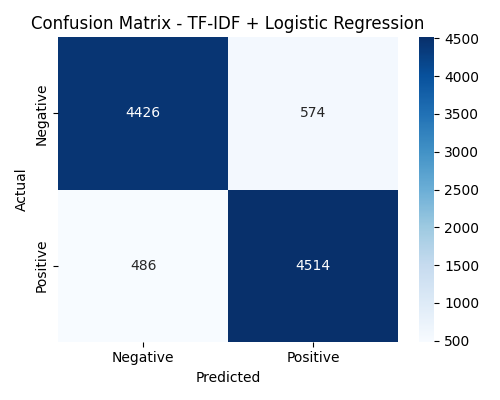

In [13]:
from IPython.display import Image
Image("confusion_matrix.png")